In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
def quadruple(y):
    ''' Quadruple y '''
    return 4*y

In [3]:
quadruple?

Signature: quadruple(y)
Docstring: Quadruple y 
File:      c:\users\ln015\appdata\local\temp\ipykernel_28992\2015895397.py
Type:      function

In [5]:
quadruple(42)

168

In [6]:
quadruple(3.14)

12.56

In [7]:
quadruple('hi mom')

'hi momhi momhi momhi mom'

In [8]:
quadruple(make_array(4, 5, 6))

array([16, 20, 24])

In [9]:
y

NameError: name 'y' is not defined

In [16]:
def percents(counts):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, 2)

In [17]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [19]:
def percents(counts, decimal_places):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [20]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

In [21]:
percents(make_array(20, 25, 30))

TypeError: percents() missing 1 required positional argument: 'decimal_places'

In [22]:
def percents(counts, decimal_places=2):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [23]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [24]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

# Applying functions to Tables

In [25]:
places = Table().with_columns(
    'Place', make_array('Fresno', 'Death Valley', 'Shaver Lake'),
    'Elevation', make_array(308, -282, 5627)
)
places

Place,Elevation
Fresno,308
Death Valley,-282
Shaver Lake,5627


In [26]:
def cut_off_at_0(val):
    return max(0, val)

In [28]:
cut_off_at_0(-5), cut_off_at_0(0), cut_off_at_0(42)

(0, 0, 42)

In [29]:
places.apply(cut_off_at_0, 'Elevation')

array([ 308,    0, 5627])

In [30]:
places.with_column('Cut off elevation', places.apply(cut_off_at_0, 'Elevation'))

Place,Elevation,Cut off elevation
Fresno,308,308
Death Valley,-282,0
Shaver Lake,5627,5627


In [31]:
cut_off_at_0

<function __main__.cut_off_at_0(val)>

In [32]:
cut = cut_off_at_0

In [33]:
cut(-5)

0

In [34]:
cut_off_at_0(42)

42

In [37]:
def calculate_total(price, tax_rate):
    result = price + price * (tax_rate / 100)
    return round(result, 2)

In [38]:
calculate_total(5.99, 8.35)

6.49

In [39]:
calculate_total(7.99, 8.75)

8.69

# Prediction

In [41]:
family_heights = Table.read_table('data/family_heights.csv').drop(3)
family_heights

family,father,mother,children,childNum,sex,childHeight
1,78.5,67,4,1,male,73.2
1,78.5,67,4,2,female,69.2
1,78.5,67,4,3,female,69
1,78.5,67,4,4,female,69
2,75.5,66.5,4,1,male,73.5
2,75.5,66.5,4,2,male,72.5
2,75.5,66.5,4,3,female,65.5
2,75.5,66.5,4,4,female,65.5
3,75,64,2,1,male,71
3,75,64,2,2,female,68


In [42]:
parent_averages = (family_heights.column('father') + family_heights.column('mother')) / 2
heights = Table().with_columns(
    'Parent Average', parent_averages,
    'Child', family_heights.column('childHeight')
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


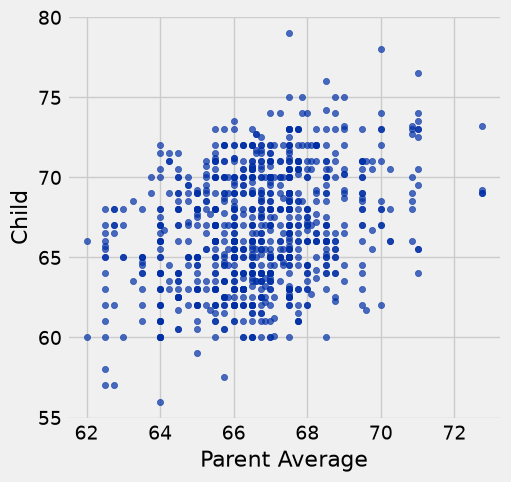

In [43]:
heights.scatter('Parent Average')

In [45]:
close_to_66 = heights.where('Parent Average', are.between(65.5, 66.5))
close_to_66

Parent Average,Child
66,62
66.25,72
66.25,70
66.25,69.5
66.25,69.5
66.25,68
66.25,65
66.25,64
66.25,63
66.25,72


In [46]:
min(close_to_66.column('Child')), max(close_to_66.column('Child'))

(57.5, 73.5)

In [47]:
np.average(close_to_66.column('Child'))

66.086407766990291

In [48]:
def predict_child(p_avg):
    close_points = heights.where('Parent Average', are.between(p_avg - 0.5, p_avg + 0.5))
    return np.average(close_points.column('Child'))

In [49]:
predict_child(66)

66.086407766990291

In [50]:
predict_child(70)

68.561904761904756

In [53]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'Parent Average')
)
heights_with_predictions

Parent Average,Child,Prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158
71,72.5,70.4158
71,65.5,70.4158
71,65.5,70.4158
69.5,71,68.5025
69.5,68,68.5025


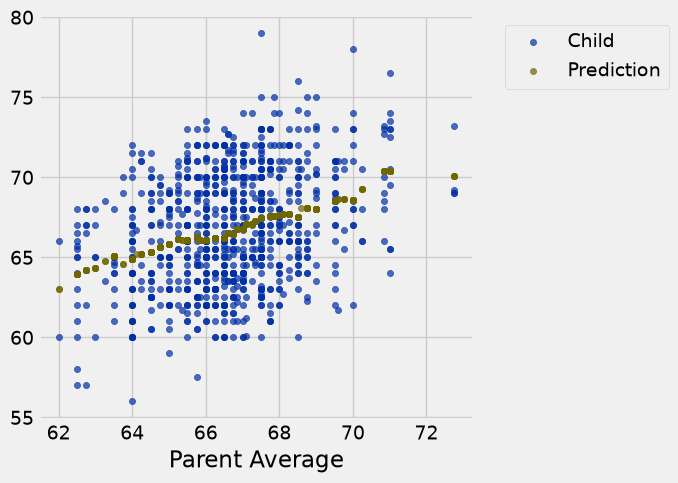

In [54]:
heights_with_predictions.scatter('Parent Average')

# Grouping

In [55]:
cones = Table.read_table('data/cones.csv')
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [56]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2
vanilla,1


In [57]:
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4
vanilla,,3.5


In [58]:
cones.group('Flavor', list)

Flavor,Color list,Price list
bubblegum,['pink'],[4.75]
chocolate,"['light brown', 'dark brown', 'dark brown']","[4.75, 5.25, 5.25]"
strawberry,"['pink', 'pink']","[3.5499999999999998, 5.25]"
vanilla,['white'],[3.5]


In [59]:
cones.group('Flavor', sum)

Flavor,Color sum,Price sum
bubblegum,,4.75
chocolate,,15.25
strawberry,,8.8
vanilla,,3.5


In [61]:
cones.drop('Color').group('Flavor', max)

Flavor,Price max
bubblegum,4.75
chocolate,5.25
strawberry,5.25
vanilla,3.5


In [62]:
pokemon = Table.read_table('data/pokemon.csv')
pokemon

abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,nan,8.5,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,nan,19,1,0
"['Blaze', 'Solar Power']",0.25,1,1,2,0.5,0.5,0.5,1,1,0.25,0,1,1,1,1,4,0.5,2,104,5120,70,634,45,Flame Pokémon,78,1059860,1.7,78,Lizardonリザードン,Charizard,88.1,6,159,115,100,fire,flying,90.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,48,5120,70,314,45,Tiny Turtle Pokémon,65,1059860,0.5,44,Zenigameゼニガメ,Squirtle,88.1,7,50,64,43,water,nan,9,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,63,5120,70,405,45,Turtle Pokémon,80,1059860,1,59,Kameilカメール,Wartortle,88.1,8,65,80,58,water,nan,22.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,103,5120,70,630,45,Shellfish Pokémon,120,1059860,1.6,79,Kamexカメックス,Blastoise,88.1,9,135,115,78,water,nan,85.5,1,0
"['Shield Dust', 'Run Away']",1,1,1,1,1,0.5,2,2,1,0.5,0.5,1,1,1,1,2,1,1,30,3840,70,195,255,Worm Pokémon,35,1000000,0.3,45,Caterpieキャタピー,Caterpie,50,10,20,20,45,bug,nan,2.9,1,0


In [63]:
p = pokemon.select('type1', 'hp')
p

type1,hp
grass,45
grass,60
grass,80
fire,39
fire,58
fire,78
water,44
water,59
water,79
bug,45


In [65]:
p.group('type1', list)

type1,hp list
bug,"[45, 50, 60, 40, 45, 65, 35, 60, 60, 70, 70, 65, 40, 55, ..."
dark,"[95, 60, 55, 45, 75, 35, 70, 50, 65, 100, 70, 70, 41, 64 ..."
dragon,"[41, 61, 91, 75, 45, 65, 95, 80, 80, 105, 58, 68, 108, 4 ..."
electric,"[35, 60, 25, 50, 40, 60, 65, 65, 90, 20, 55, 70, 90, 45, ..."
fairy,"[70, 95, 50, 35, 55, 60, 90, 85, 44, 74, 78, 78, 101, 62 ..."
fighting,"[40, 65, 70, 80, 90, 50, 50, 35, 50, 72, 144, 30, 60, 40 ..."
fire,"[39, 58, 78, 38, 73, 55, 90, 50, 65, 65, 65, 90, 39, 58, ..."
flying,"[79, 40, 85]"
ghost,"[30, 45, 60, 60, 44, 64, 20, 40, 90, 150, 60, 50, 45, 15 ..."
grass,"[45, 60, 80, 45, 60, 75, 50, 65, 80, 60, 95, 65, 45, 60, ..."


In [68]:
p.group('type1', np.average).sort('hp average', descending=True)

type1,hp average
dragon,79.8519
normal,76.7238
fairy,73.9444
ground,73.1875
psychic,72.9434
dark,72.5517
ice,72.087
fighting,71.4286
water,70.2193
fire,68.7308


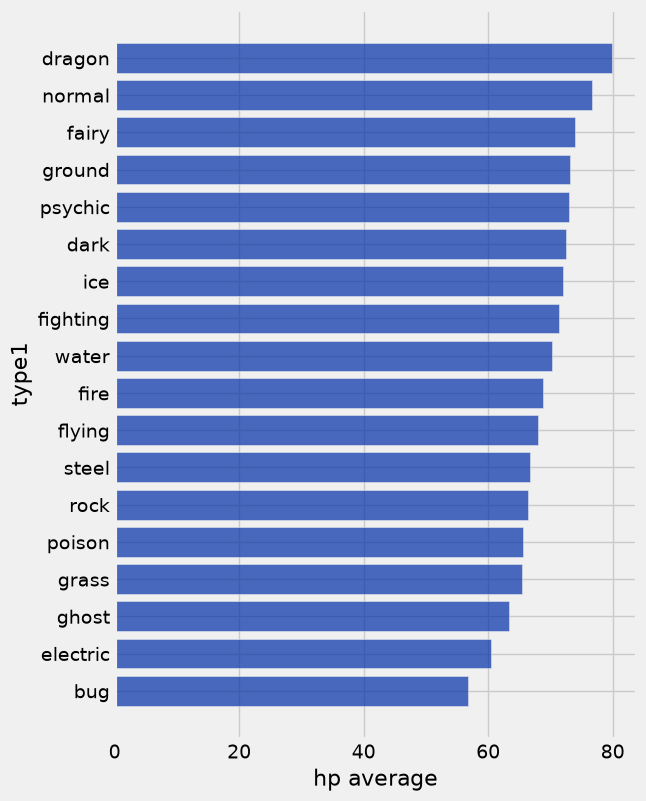

In [69]:
p.group('type1', np.average).sort('hp average', descending=True).barh('type1')

In [74]:
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [76]:
cones.group(make_array('Flavor', 'Color'))

Flavor,Color,count
bubblegum,pink,1
chocolate,dark brown,2
chocolate,light brown,1
strawberry,pink,2
vanilla,white,1


In [77]:
cones.group(make_array('Flavor', 'Color'), min)

Flavor,Color,Price min
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,3.55
vanilla,white,3.5


In [78]:
cones.group(['Flavor', 'Color'], min)

Flavor,Color,Price min
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,3.55
vanilla,white,3.5


---